# ML Model Comparison: Linear Regression, Logistic Regression & Naive Bayes


Read Replace every `# TODO` with your own code and answer every **Q** in a markdown cell.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics

RANDOM_STATE = 42

## Part 0 — Load & explore `student_performance.csv`

In [2]:
df = pd.read_csv('data/student_performance.csv')
df.head()

,student_id,gender,study_hours_per_day,attendance_pct,sleep_hours,previous_score,internet_access,private_tuition,extracurriculars,final_score,result
0,1,M,7.7,53.1,5.8,52.8,Yes,No,3,59.3,Fail
1,2,F,4.4,72.9,8.1,71.4,No,Yes,1,60.2,Pass
2,3,F,8.6,56.5,5.6,66.4,Yes,No,1,73.6,Pass
3,4,M,7.0,57.6,6.7,67.2,Yes,No,3,60.6,Pass
4,5,M,0.9,81.6,6.3,88.4,Yes,Yes,1,61.5,Pass


In [3]:
# TODO: df.info(), df.describe(), count missing values per column
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           1000 non-null   int64  
 1   gender               1000 non-null   str    
 2   study_hours_per_day  1000 non-null   float64
 3   attendance_pct       985 non-null    float64
 4   sleep_hours          985 non-null    float64
 5   previous_score       985 non-null    float64
 6   internet_access      1000 non-null   str    
 7   private_tuition      1000 non-null   str    
 8   extracurriculars     1000 non-null   int64  
 9   final_score          1000 non-null   float64
 10  result               1000 non-null   str    
dtypes: float64(5), int64(2), str(4)
memory usage: 86.1 KB


student_id              0
gender                  0
study_hours_per_day     0
attendance_pct         15
sleep_hours            15
previous_score         15
internet_access         0
private_tuition         0
extracurriculars        0
final_score             0
result                  0
dtype: int64

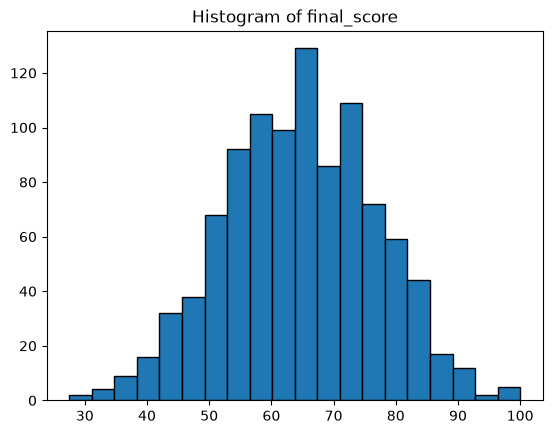

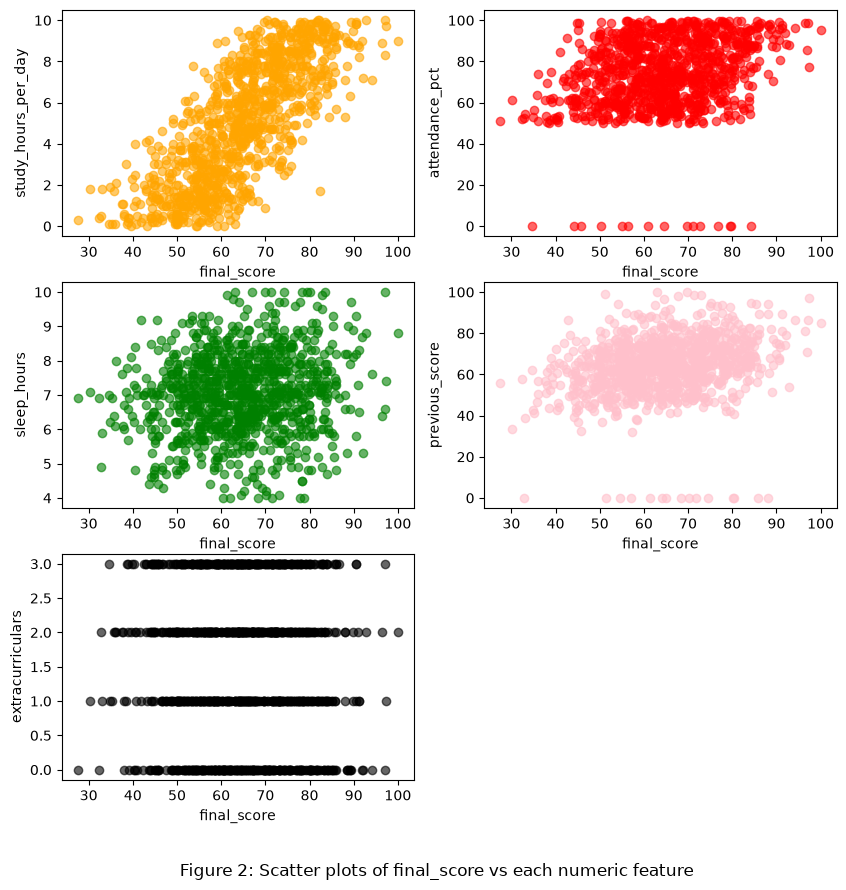

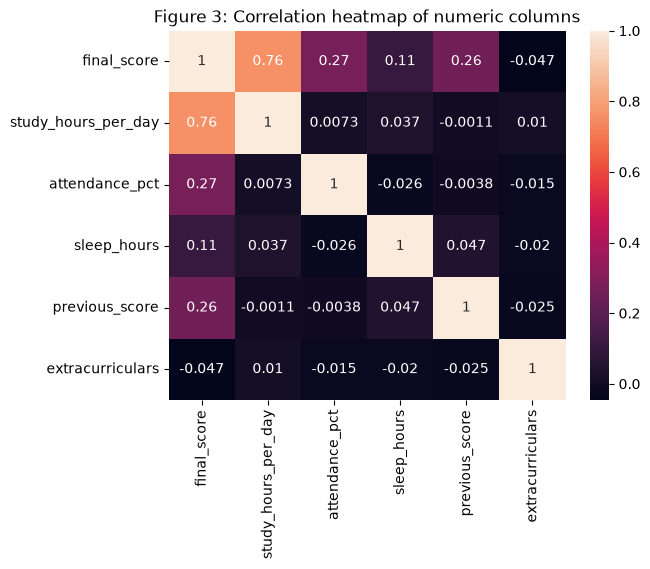

In [4]:
# TODO: histogram of final_score; scatter plots of final_score vs each numeric feature
plt.title("Histogram of final_score")
plt.hist(df['final_score'], bins=20, edgecolor="black")
plt.show()

final = df['final_score']
data = ['study_hours_per_day', 'attendance_pct', 'sleep_hours', 'previous_score', 'extracurriculars']
colors = ['orange', 'red', 'green', 'pink', 'black']

sleep_filled = df['sleep_hours'].fillna(df.sleep_hours.mean())
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for ax, ylab, c in zip(axes.flat, data, colors):
    x = sleep_filled if ylab == "sleep_hours" else df[ylab].fillna(0)
    ax.scatter(final, x, color=c, alpha=0.6)
    ax.set_xlabel("final_score")
    ax.set_ylabel(ylab)
axes.flat[-1].axis("off")
fig.supxlabel("Figure 2: Scatter plots of final_score vs each numeric feature")
plt.show()
# TODO: correlation heatmap of numeric columns (sns.heatmap)
dffinal = df[['final_score', *data]].fillna(0)
sns.heatmap(data=dffinal.corr(), annot=True)
plt.title("Figure 3: Correlation heatmap of numeric columns")
plt.show()

**Q0.** Which feature looks most related to `final_score`? Are there missing values, and how will you handle them?

Ans:- The feature that looks most related to `final_score` is `study_hours_per_day`, as per the scatterplot in top right in figure 2, and in figure 3. as w.r.t `study_hourse_per_day`, `final_score` gets more higher value.

There are some missing values as in `attendance_pct=15`, `sleep_hours=15` and `previous_score=15`, we filled the missing values for `attendance_pct` and `previous_score` with `0` as both can be 0 respectively and we filled `sleep_hours` with the mean of the same column as sleep hours cann't be `0`.

## Preprocessing (shared by Parts A & B)

In [22]:
num = ['study_hours_per_day', 'attendance_pct', 'sleep_hours', 'previous_score', 'extracurriculars']
cat = ['gender', 'internet_access', 'private_tuition']

# TODO: build a ColumnTransformer:
#   numeric -> SimpleImputer(median) + StandardScaler
#   categorical -> OneHotEncoder(drop='if_binary')
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer([
    ('num', num_pipe, num),
    ('cat', cat_pipe, cat)
])
X = df[num + cat]

## Part A — Linear Regression: predict `final_score`

In [23]:
y = df['final_score']
# TODO: 80/20 train_test_split with random_state=RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)


The r2 score is:  0.5667234369273191


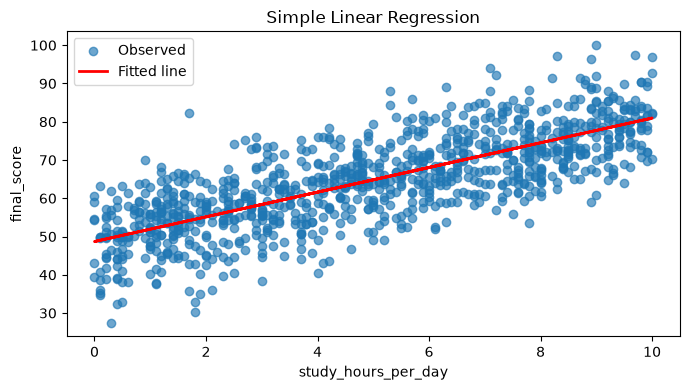

In [24]:
# A1. Simple linear regression using ONLY study_hours_per_day
# TODO: fit, report R², plot data + fitted line
reg_mul = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('model', LinearRegression())
])
reg_mul.fit(X_train[['study_hours_per_day']], y_train)
y_pred = reg_mul.predict(X_test[['study_hours_per_day']])
r2 = metrics.r2_score(y_test, y_pred)
print(f"The r2 score is: ", r2)

x_all = df[['study_hours_per_day']].copy()
x_all['study_hours_per_day'] = x_all['study_hours_per_day'].fillna(
    X_train['study_hours_per_day'].median()
)
y_all_pred = reg_mul.predict(x_all)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df['study_hours_per_day'], y, alpha=0.65, label='Observed')
ax.plot(
    x_all['study_hours_per_day'],
    y_all_pred,
    linewidth=2,
    label='Fitted line',
    color="red"
)
ax.set_xlabel('study_hours_per_day')
ax.set_ylabel('final_score')
ax.set_title('Simple Linear Regression')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# A2. Multiple linear regression with all features (Pipeline: pre -> LinearRegression)
# TODO: report MAE, RMSE, R² on the test set
reg_mul = Pipeline([
    ('pre', pre),
    ('model', LinearRegression())
])

reg_mul.fit(X_train, y_train)
y_pred_a2 = reg_mul.predict(X_test)

mae = metrics.mean_absolute_error(y_test, y_pred_a2)
rmse = metrics.mean_squared_error(y_test, y_pred_a2)
r2_mul = metrics.r2_score(y_test, y_pred_a2)

print(f"A2 MAE : {mae:.4f}")
print(f"A2 RMSE: {rmse:.4f}")
print(f"A2 R²  : {r2_mul:.4f}")
print(f"R² improvement over A1: {r2_mul - r2:.4f}")

A2 MAE : 3.9907
A2 RMSE: 24.7087
A2 R²  : 0.8203
R² improvement over A1: 0.2535


,feature,coefficient
0,num__study_hours_per_day,9.192896
1,num__previous_score,3.994331
2,num__attendance_pct,3.869227
3,cat__private_tuition_Yes,3.350368
4,cat__internet_access_Yes,2.828273
5,num__sleep_hours,1.403804
6,num__extracurriculars,-0.656796
7,cat__gender_M,0.225709


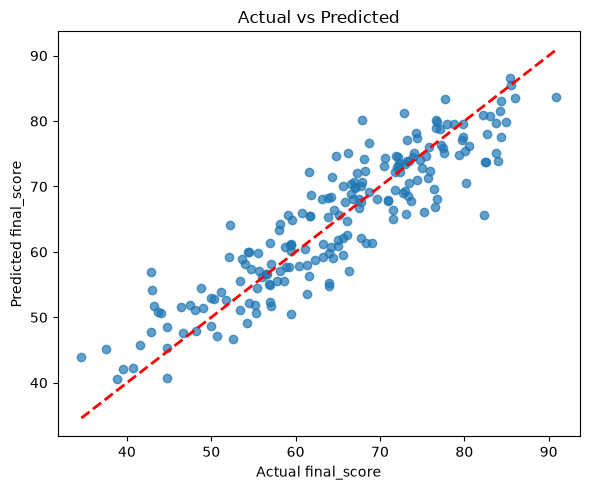

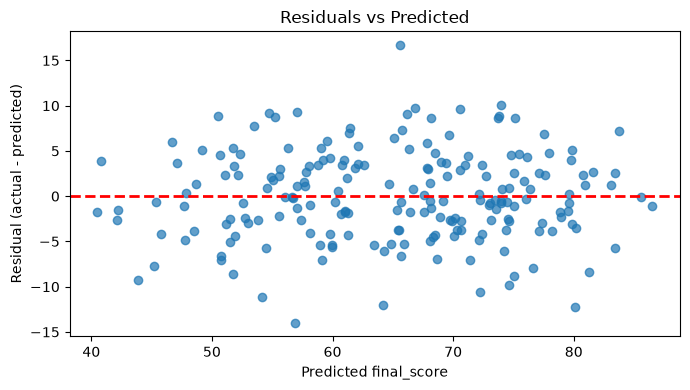

In [32]:
# A3. TODO: table of coefficients (use pre.get_feature_names_out()), sorted
fitted_pre = reg_mul.named_steps['pre']
coef = reg_mul.named_steps['model'].coef_
feature_names = fitted_pre.get_feature_names_out()
coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef,
    'abs_coefficient': np.abs(coef),
}).sort_values('abs_coefficient', ascending=False)

display(coef_table.drop(columns='abs_coefficient').reset_index(drop=True))

# A4. TODO: Actual-vs-Predicted plot and Residuals-vs-Predicted plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_a2, alpha=0.7)
lims = [min(y_test.min(), y_pred_a2.min()), max(y_test.max(), y_pred_a2.max())]
ax.plot(lims, lims, linestyle='--', linewidth=2, color="red")
ax.set_xlabel('Actual final_score')
ax.set_ylabel('Predicted final_score')
ax.set_title('Actual vs Predicted')
plt.tight_layout()
plt.show()

# Residuals-vs-Predicted plot
residuals = y_test.to_numpy() - y_pred_a2
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(y_pred_a2, residuals, alpha=0.7)
ax.axhline(0, linestyle='--', linewidth=2, color="red")
ax.set_xlabel('Predicted final_score')
ax.set_ylabel('Residual (actual - predicted)')
ax.set_title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

**Q-A.** (1) Interpret the top 3 coefficients in plain English. Why did we scale features before comparing them?

  #### Ans(1): the top 3 coefficient are
  - Study_hours_per_day (9.19): Holding other features constant, a one-standard-deviation increase in the variable , increases the final score 
    by ~9.19.
  - Previous Score (3.99): Holding other features constant, a one-standard-deviation increase in this variable, increases the final score by ~3.99.
  - Attendance Percantage (3.87): Holding other features constant, a one-standard-deviation increase in this variable, increases the final score by 
    ~3.87.

      ##### We scale the features so we can measure numerical variables with different units, i.e. hours, percentage etc. This makes their coefficients magnitudes easier to compare. without it the measurements can be misleading as the features use different scales of units.
      
(2) How much did R² improve from A1 to A2? 
  #### Ans(2): The R² score improved by 0.2535, from approximately 0.5668 in A1 to 0.8203 in A2. 
(3) Do the residuals look random? What would a pattern mean?
  #### Ans(3): Yes, the residuals appear to be randomly scattered around zero, with no obvious curved or funnel-shaped pattern. This suggests that the linear regression model captures the main relationship between the features and the final score reasonably well, and there is no strong visual evidence of nonlinearity or non-constant error variance.
  #### However, a few residuals are relatively large, indicating that the model makes larger prediction errors for some students. A curved pattern would suggest a nonlinear relationship, a funnel shape would indicate potentially non-constant error variance, and clusters or other systematic patterns could suggest missing features or interactions. 

## Part B — Logistic Regression: predict `result` (Pass/Fail)
⚠️ Do **not** use `final_score` as a feature — explain why in Q-B.

In [33]:
yb = (df['result'] == 'Pass').astype(int)
# TODO: stratified 80/20 split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, yb, test_size=0.20, random_state=RANDOM_STATE, stratify=yb
)
print(f"Train size: {len(X_train_b)}, Test size: {len(X_test_b)}")
print("Class balance in test set:")
display(y_test_b.value_counts(normalize=True).rename({0: 'Fail', 1: 'Pass'}))

Train size: 800, Test size: 200
Class balance in test set:


result
Pass    0.64
Fail    0.36
Name: proportion, dtype: float64

Accuracy : 0.8800
Precision: 0.9127
Recall   : 0.8984
F1       : 0.9055
ROC-AUC  : 0.9513

Confusion matrix (rows=actual, columns=predicted; 0=Fail, 1=Pass):


,Predicted Fail,Predicted Pass
Actual Fail,61,11
Actual Pass,13,115


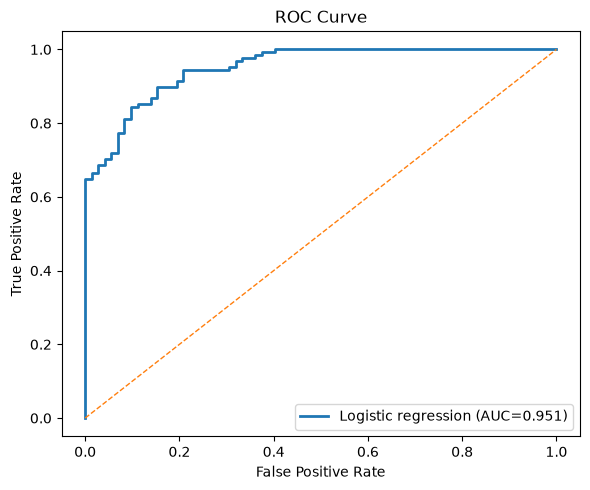

In [35]:
# B1. TODO: Pipeline(pre -> LogisticRegression(max_iter=1000)); fit
log_reg = Pipeline([
    ('pre', pre),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
log_reg.fit(X_train_b, y_train_b)
# B2. TODO: accuracy, precision, recall, F1, ROC-AUC, confusion matrix, ROC curve

y_prob_b = log_reg.predict_proba(X_test_b)[:, 1]
y_pred_b = (y_prob_b >= 0.50).astype(int)

accuracy = metrics.accuracy_score(y_test_b, y_pred_b)
precision = metrics.precision_score(y_test_b, y_pred_b, zero_division=0)
recall = metrics.recall_score(y_test_b, y_pred_b, zero_division=0)
f1 = metrics.f1_score(y_test_b, y_pred_b, zero_division=0)
roc_auc = metrics.roc_auc_score(y_test_b, y_prob_b)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

cm = metrics.confusion_matrix(y_test_b, y_pred_b)
print("\nConfusion matrix (rows=actual, columns=predicted; 0=Fail, 1=Pass):")
display(pd.DataFrame(cm, index=['Actual Fail', 'Actual Pass'], columns=['Predicted Fail', 'Predicted Pass']))

fpr, tpr, _ = metrics.roc_curve(y_test_b, y_prob_b)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, linewidth=2, label=f'Logistic regression (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
# B3. TODO: odds ratios = np.exp(coef_); sorted table
fitted_log_pre = log_reg.named_steps['pre']
log_coef = log_reg.named_steps['model'].coef_[0]
log_feature_names = fitted_log_pre.get_feature_names_out()

odds_table = pd.DataFrame({
    'feature': log_feature_names,
    'coefficient': log_coef,
    'odds_ratio': np.exp(log_coef),
}).sort_values('odds_ratio', ascending=False)

display(odds_table.reset_index(drop=True))
# B4. TODO: precision & recall at thresholds 0.3, 0.5, 0.7 using predict_proba

threshold_rows = []
for threshold in [0.3, 0.5, 0.7]:
    pred_at_t = (y_prob_b >= threshold).astype(int)
    threshold_rows.append({
        'threshold': threshold,
        'precision': metrics.precision_score(y_test_b, pred_at_t, zero_division=0),
        'recall': metrics.recall_score(y_test_b, pred_at_t, zero_division=0),
        'f1': metrics.f1_score(y_test_b, pred_at_t, zero_division=0),
    })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

,feature,coefficient,odds_ratio
0,num__study_hours_per_day,2.970054,19.492964
1,num__previous_score,1.360584,3.898470
2,cat__private_tuition_Yes,1.003401,2.727541
3,num__attendance_pct,0.945030,2.572889
4,cat__internet_access_Yes,0.400854,1.493099
5,num__sleep_hours,0.304240,1.355595
6,num__extracurriculars,-0.139034,0.870198
7,cat__gender_M,-0.271124,0.762522


,threshold,precision,recall,f1
0,0.3,0.847222,0.953125,0.897059
1,0.5,0.912698,0.898438,0.905512
2,0.7,0.944954,0.804688,0.869198


**Q-B.** (1) Why would using `final_score` be cheating (target leakage)?

Ans(1): Using final_score as a feature would cause target leakage because the result label (Pass/Fail) is determined by the student's final outcome. The model would have access to information that would not legitimately be available when predicting whether a student is at risk before the final examination.

(2) Interpret the largest odds ratio.

Ans(2): The largest odds ratio is for study_hours_per_day, with an odds ratio of ~19.49. Since the class encoding is Fail = 0 and Pass = 1, an odds ratio above 1 indicates higher odds of passing.

Holding other features constant, a one-standard-deviation increase in study hours multiplies the odds of passing by approximately ~19.49, assuming the numerical features were standardized. This describes an association learned by the model, not necessarily a causal effect.

(3) If the college wants to catch *every* at-risk (Fail) student for remedial classes, which threshold and which metric matter most?

Ans(3): The most important metric is recall for the Fail class, because it measures the proportion of students who actually fail that the model correctly identifies.

Since Fail is encoded as 0 and Pass as 1, the existing threshold table calculates precision, recall, and F1 for the Pass class. Therefore, the table alone cannot establish which threshold is best for identifying failing students.

To evaluate Fail detection, calculate $( P(\text{Fail}) = 1 - P(\text{Pass}) )$, then compare recall for Fail at different thresholds. A lower threshold for predicting Fail generally increases recall but may also increase false positives, causing more students who would pass to be flagged for remedial classes.

## Part C — Naive Bayes: SMS spam filter (`sms_spam.csv`)

In [ ]:
sms = pd.read_csv('data/sms_spam.csv')
# TODO: class counts, average message length per class, 5 sample messages of each class


In [ ]:
ys = (sms.label == 'spam').astype(int)
# TODO: stratified 80/20 split of sms.message


In [ ]:
# C1. TODO: Pipeline(CountVectorizer -> MultinomialNB); report accuracy, precision, recall, F1, confusion matrix
# C2. TODO: compare CountVectorizer vs TfidfVectorizer and alpha in [0.01, 0.1, 1, 5] -> results table


In [ ]:
# C3. TODO: top 10 'spam' and 'ham' words using nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
# C4. TODO: classify 5 messages you write yourself; 5-fold cross_val_score (scoring='f1')


In [ ]:
# C5. TODO: train LogisticRegression on the same CountVectorizer features and compare F1


**Q-C.** (1) What is the 'naive' assumption, and why does NB still work well for text? (2) What does `alpha` (Laplace smoothing) do?
(3) For a spam filter, is a false positive or a false negative worse? Which metric would you optimise?
(4) Look at 3 misclassified messages — why did the model get them wrong?

## Part D — Comparison & Conclusion
**TODO:** Fill a summary table (model, task, best metric) and write 150–200 words: when would you choose each algorithm?